# Testing Libraries

In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=1
!export BART_CPU_ONLY=1
!export CUDA_LAUNCH_BLOCKING=1

import importlib
import sys
import os

os.environ['BART_TOOLBOX_PATH'] = '/home/rinbha/bart-0.9.00'
os.environ['BART_CPU_ONLY'] = '1'
sys.path.append(os.path.join(os.environ['BART_TOOLBOX_PATH'], 'python'))
sys.path.append(os.path.abspath('/home/rinbha/orchestra-sdk-2.1-1.python/'))

sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/nonrigid-motion-bpt")
sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/bpt_mrmotus_2025/bpt_mrmotus_2025/mrmotus_custom_packages/sigpy-custom")
sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/bpt_mrmotus_2025/bpt_mrmotus_2025/mrmotus_custom_packages/torch-interpol")
import sigpy as sp
import sigpy.mri as mr
import sigpy.plot as pl

import matplotlib.pyplot as plt
import numpy as np

# plotting
%matplotlib widget
plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 20,               # Increase title font size
    'axes.labelsize': 18,               # Increase axis label font size
    'xtick.labelsize': 16,              # Increase x-tick label size
    'ytick.labelsize': 16,              # Increase y-tick label size
    "text.usetex": False,                # Enable LaTeX 
    'legend.fontsize': 12,
    'font.family': 'Avenir' # Avenir font
})

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=1


/home/rinbha/miniconda3/envs/cmr-motus/lib/python3.9/site-packages/cupy/_environment.py:445: UserWarning: 
nccl library could not be loaded.

Reason: ImportError (libnccl.so.2: cannot open shared object file: No such file or directory)

You can install the library by:
  $ python -m cupyx.tools.install_library --library nccl --cuda 12.x

  warnings.warn(f'''


## io

### Radial

In [5]:
# add paths
from bpt_motus.io import RadialArchive

In [17]:
import bpt_motus.io.radial_reader as rr
importlib.reload(rr)

from bpt_motus.io.radial_reader import RadialArchive

In [ ]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/hires_ute"

# Create the object
radial = RadialArchive(inpdir)

radial.get_ksp(force_reload=False)

INFO: Loading cached raw radial data from /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/phantom_ute_121725/Series3...


In [22]:
print(f"xk shape: {radial.xk_time.shape}")
print(f"coords shape: {radial.coords_time.shape}")
print(f"dcf shape: {radial.dcf_time.shape}")
print(f"time_ordering shape: {radial.time_ordering.shape}")

xk shape: (32, 49951, 621)
coords shape: (49951, 621, 3)
dcf shape: (49951, 621)
time_ordering shape: (49951,)


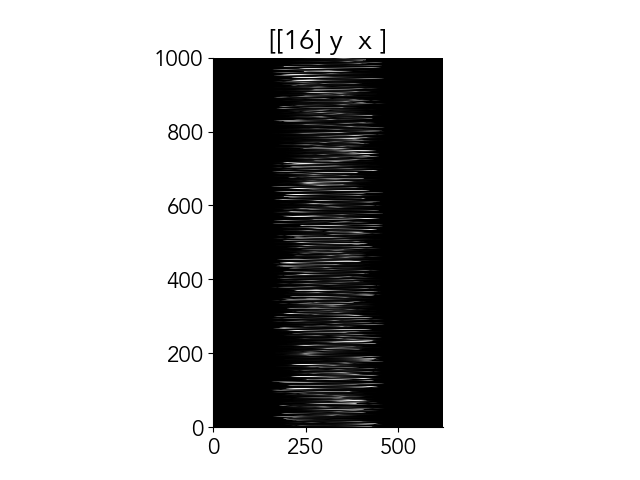

In [24]:
xk_f = sp.ifft(radial.xk_time[:,:1000], axes=(-1,))
pl.ImagePlot(xk_f)

In [12]:
del radial

### Bravo

In [25]:
from bpt_motus.io import BravoArchive

In [26]:
import bpt_motus.io.bravo_reader as br
importlib.reload(br)

from bpt_motus.io.bravo_reader import BravoArchive

In [ ]:
# Path to BRAVO ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bravo"

# Create the object
bravo = BravoArchive(inpdir)

bravo.get_ksp(force_reload=False)

INFO: Loading cached k-space from /mikLKS/rinbha/BPT/MRMOTUS/test_data/bravo/raw_data/data_dict.pkl


In [28]:
for key in bravo.data_dict.keys():
    print(f"{key} shape: {bravo.data_dict[key].shape}")

xk_time shape: (22, 58520, 384)
xk_recon shape: (22, 384, 308, 190)
coords shape: (58520, 384, 3)


In [29]:
im_recon = sp.ifft(bravo.data_dict['xk_recon'], axes=(-1,-2,-3))

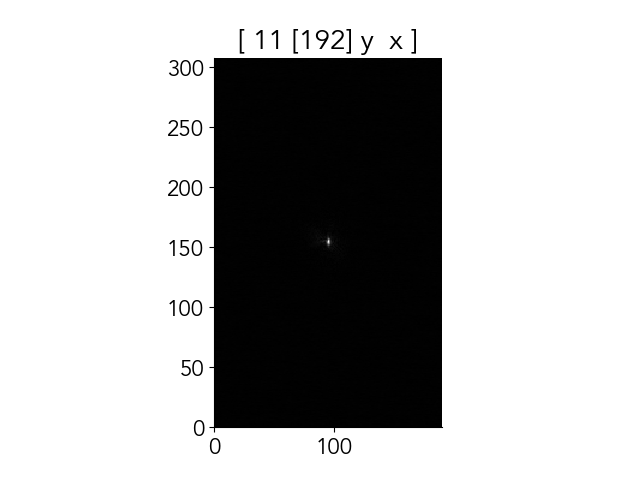

In [30]:
pl.ImagePlot(bravo.data_dict['xk_recon'])

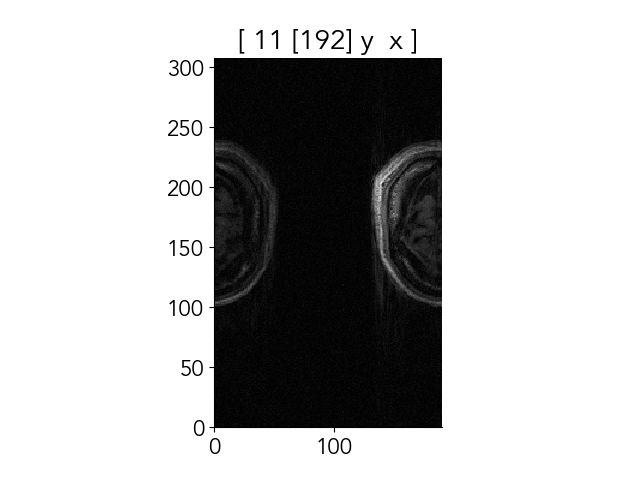

In [32]:
pl.ImagePlot(im_recon)

In [33]:
del bravo, im_recon

### Organize Radial Acquisitions into Phases

In [28]:
from bpt_motus.io import SplitRadialAcq

In [29]:
import bpt_motus.io.acq_splitter as acs
importlib.reload(acs)

from bpt_motus.io.acq_splitter import SplitRadialAcq

In [33]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/"
calib_source="hires"
no_motion_range=(0,15000)
calib_range=(20000,35000)
inf_range=(35000, None)
# Create the object
split_exp = SplitRadialAcq(inp_dir=inpdir, verbose=True, calib_source=calib_source, no_motion_range=no_motion_range, calib_range=calib_range, inf_range=inf_range)

In [31]:
split_exp.run(force_reload=True)

INFO: Generating no motion dataset.
INFO: Generating calibration dataset.
INFO: Generating inference dataset.


## preprocessing

### Split k-space and BPT

In [2]:
from bpt_motus.preprocessing import SplitXkBPT

In [29]:
import bpt_motus.preprocessing.split_xk_bpt as sxb
importlib.reload(sxb)

from bpt_motus.preprocessing.split_xk_bpt import SplitXkBPT

In [7]:
# Split no motion data
nomotion_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/no_motion"
split_xk_bpt_nm = SplitXkBPT(inp_dir=nomotion_inpdir, verbose=True)
split_xk_bpt_nm.run()
# Split calibration data
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
split_xk_bpt_c = SplitXkBPT(inp_dir=calib_inpdir, verbose=True)
split_xk_bpt_c.run()
# Split inference data
inf_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf"
split_xk_bpt_inf = SplitXkBPT(inp_dir=inf_inpdir, verbose=True)
split_xk_bpt_inf.run()

INFO: Cleaned k-space and raw BPT/PT signals found. Opening...
INFO: Cleaned k-space and raw BPT/PT signals found. Opening...
INFO: Cleaned k-space and raw BPT/PT signals found. Opening...


In [8]:
print(f"Cleaned k-space shape: {split_xk_bpt_nm.xk_cleaned.shape}")
print(f"BPT/PTs shape: {split_xk_bpt_nm.bpts.shape}")

Cleaned k-space shape: (6, 15000, 1633)
BPT/PTs shape: (4, 15000, 22)


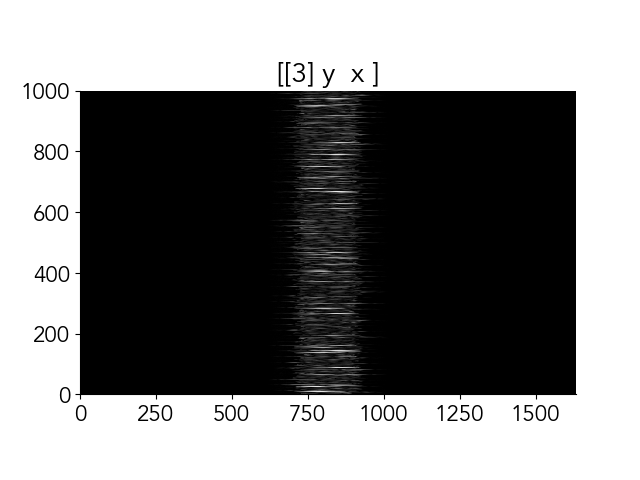

In [11]:
xk_f = sp.ifft(split_xk_bpt_nm.xk_cleaned[:,:1000], axes=(-1,))
pl.ImagePlot(xk_f)

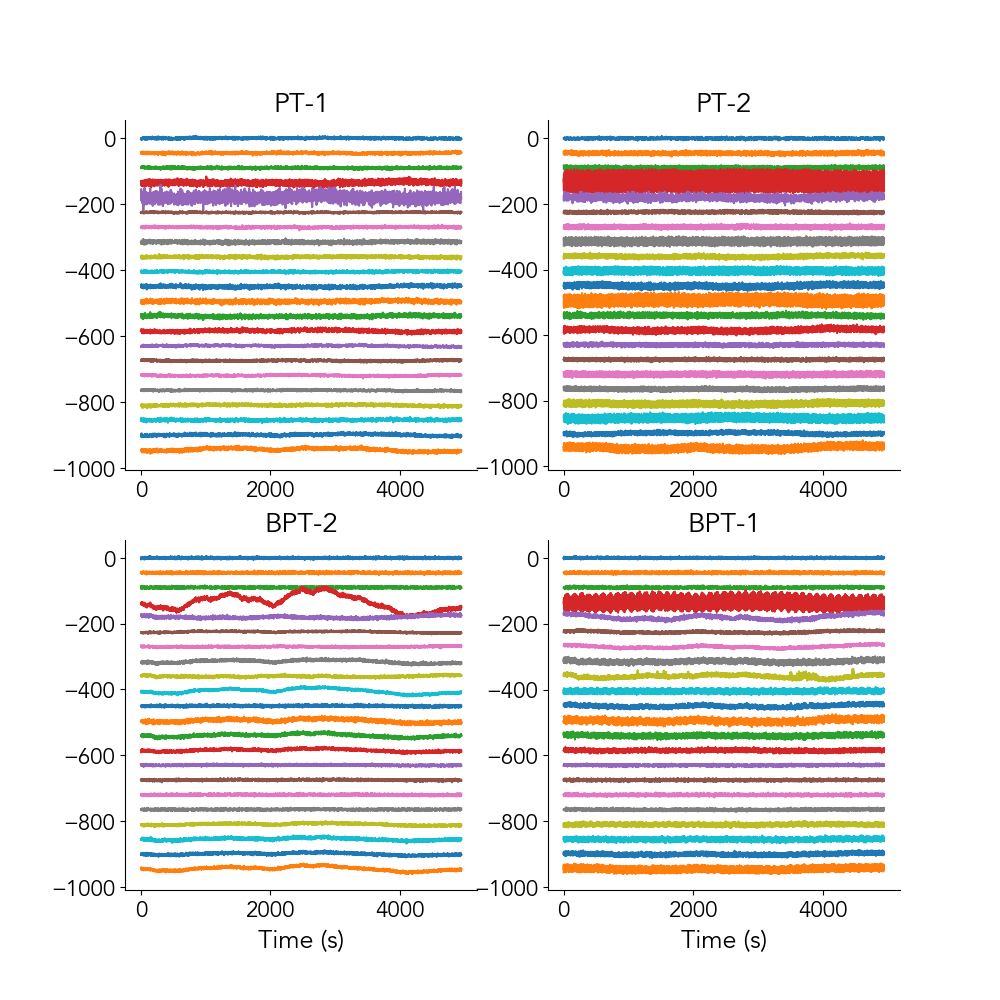

In [13]:
def plot_bpt(bpt, tr=1, window=1, shift=0, figsize=(10,10), titles = ["PT-1", "PT-2", "BPT-2", "BPT-1"]):
    nbpts, npe, ncoils = bpt.shape
    
    plt.figure(figsize=figsize)
    t = np.arange(npe)*tr
    # Plot
    for i in range(nbpts):
        plt.subplot(nbpts//2, 2, i+1)
        plt.plot(t, bpt[i] - np.mean(bpt[i],axis=0) + np.arange(ncoils)*shift);
        plt.title(titles[i])
        if i > 1:
            plt.xlabel("Time (s)")

plot_bpt(split_xk_bpt_inf.bpts, shift = -45)

### Process BPT/PTs

In [23]:
from bpt_motus.preprocessing import ProcessBPT

In [42]:
import bpt_motus.preprocessing.process_bpt as pbpt
importlib.reload(pbpt)

from bpt_motus.preprocessing.process_bpt import ProcessBPT

In [ ]:
# Process calibration BPT
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
proc_bpt_c = ProcessBPT(inp_dir=calib_inpdir, verbose=True, phase="calib")
proc_bpt_c.run()
# Process inference BPT
inf_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf"
proc_bpt_i = ProcessBPT(inp_dir=inf_inpdir, verbose=True, phase="inf")
proc_bpt_i.run()

INFO: Processed BPT/PTs not found. Extracting them...
INFO: TR found from metadata: 5.85 ms
SSA: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:08<00:00, 10.74it/s]
INFO: Processed BPT/PTs not found. Extracting them...
INFO: TR found from metadata: 5.85 ms
SSA: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:03<00:00, 23.07it/s]


In [47]:
print(f"Processed BPT shape (calib): {proc_bpt_c.bpts_proc.shape}")
print(f"Processed BPT shape (inf): {proc_bpt_i.bpts_proc.shape}")

Processed BPT shape (calib): (15000, 16)
Processed BPT shape (inf): (4950, 16)


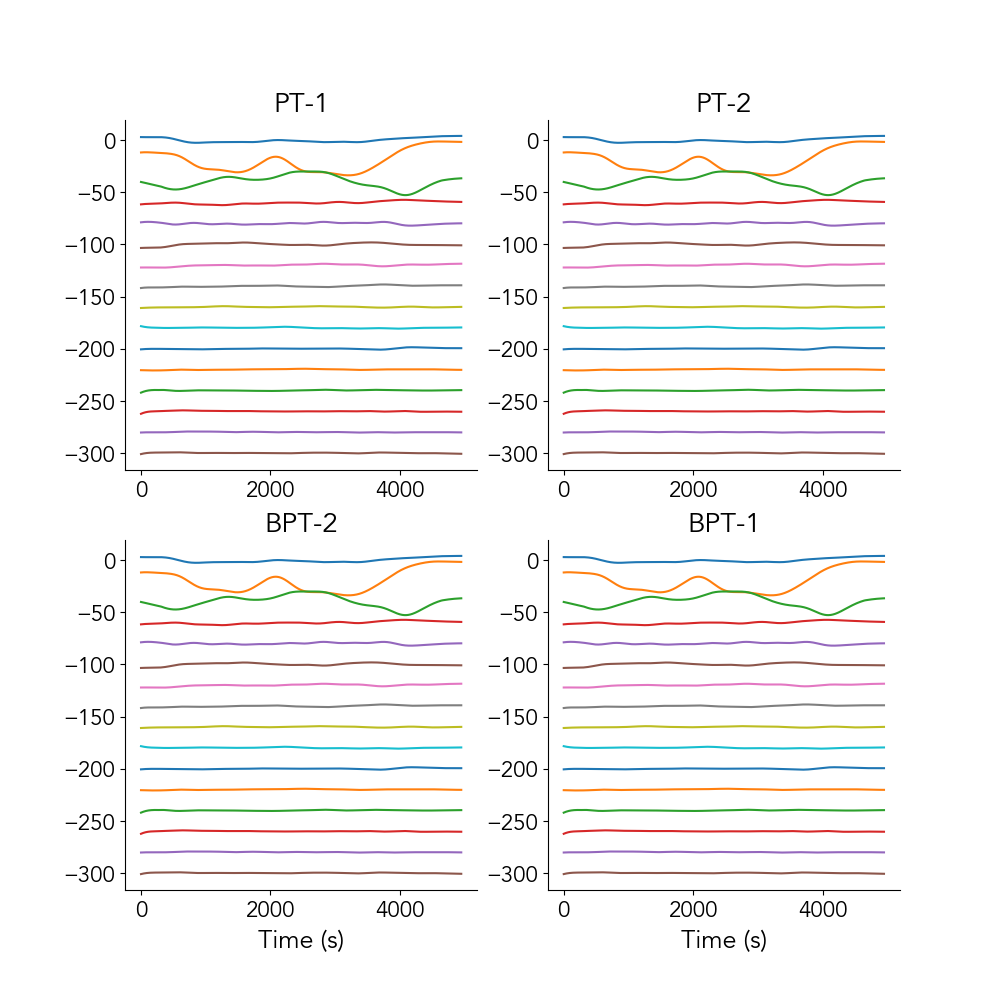

In [53]:
plot_bpt(np.tile(proc_bpt_i.bpts_proc, (4,1,1)), shift = -20)

### Process xk

#### No Motion Reference

In [51]:
from bpt_motus.preprocessing import NoMotionReference

In [25]:
import bpt_motus.preprocessing.process_xk as px
importlib.reload(px)

from bpt_motus.preprocessing.process_xk import NoMotionReference

In [ ]:
# Path to no motion folder
nomotion_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/no_motion"

# Create the object
no_motion_reference = NoMotionReference(inp_dir=nomotion_inpdir, verbose=True)

In [ ]:
no_motion_reference.run(force_reload=False)

In [56]:
S_old = np.load("/mikLKS/rinbha/BPT/MRMOTUS/results/bpt_volunteer_110924_2_results/Hires_No_Motion/Crop_3/S_nomotion_hires.npy")
csm_old = np.load("/mikLKS/rinbha/BPT/MRMOTUS/results/bpt_volunteer_110924_2_results/Hires_No_Motion/Crop_3/csm_hires.npy")

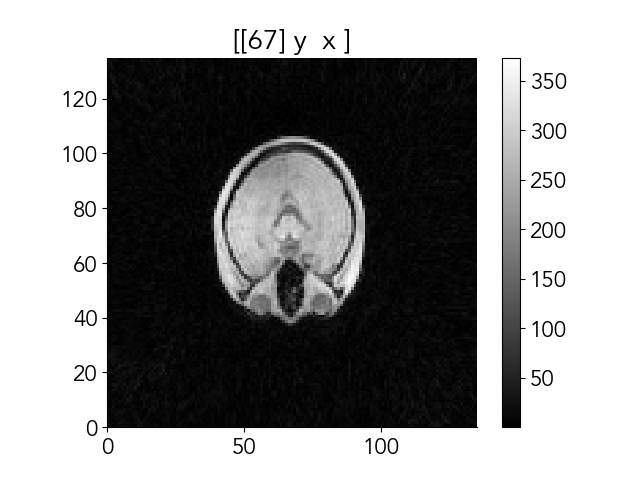

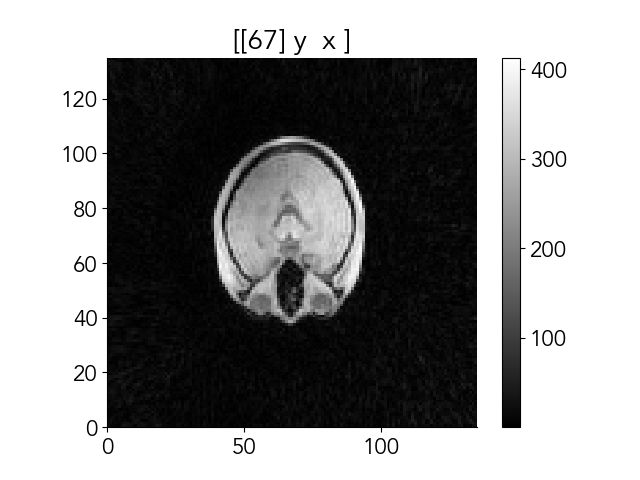

In [57]:
pl.ImagePlot(S_old, colormap='gray')
pl.ImagePlot(no_motion_reference.S, colormap='gray')

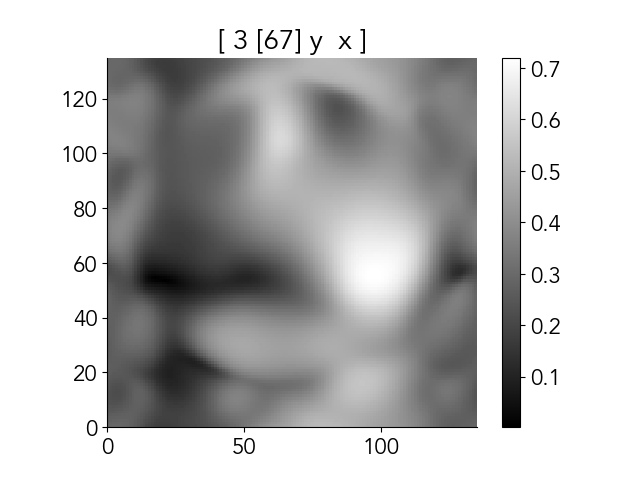

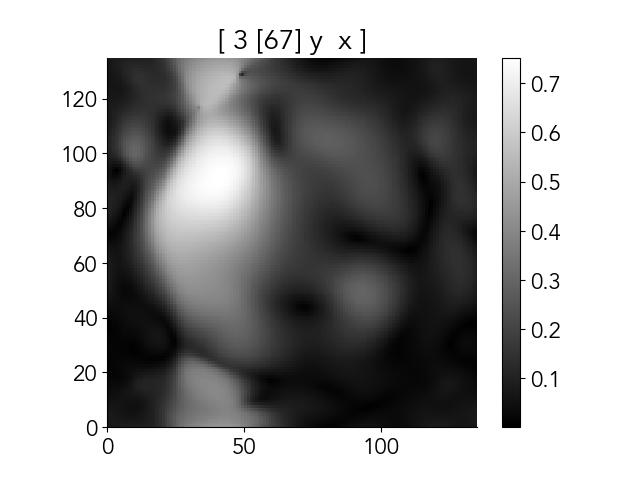

In [58]:
pl.ImagePlot(csm_old, colormap='gray')
pl.ImagePlot(no_motion_reference.csm, colormap='gray')

#### Motion Frames

In [59]:
from bpt_motus.preprocessing import MotionFrames

In [75]:
import bpt_motus.preprocessing.process_xk as px
importlib.reload(px)

from bpt_motus.preprocessing.process_xk import MotionFrames

In [ ]:
# Process calibration k-space with motion
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
motion_frames_c = MotionFrames(inp_dir=calib_inpdir, verbose=True)
motion_frames_c.run(force_reload=True)
# Process inference k-space with motion
inf_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf"
motion_frames_i = MotionFrames(inp_dir=inf_inpdir, verbose=True)
motion_frames_i.run(force_reload=True)

INFO: Radial acquisition split into frames not found. Extracting with crop factor 8...
INFO: Getting xk, coords, dcf, and bpts from radial data.
INFO: Cropping spokes by 8.
INFO: Splitting radial data into frames.
INFO: Radial acquisition split into frames not found. Extracting with crop factor 8...
INFO: Getting xk, coords, dcf, and bpts from radial data.
INFO: Cropping spokes by 8.
INFO: Splitting radial data into frames.


In [77]:
print(f"Motion frames shape (calib): {motion_frames_c.xk_frames.shape}")
print(f"Inference frames shape (calib): {motion_frames_i.xk_frames.shape}")

Motion frames shape (calib): (6, 146, 500, 205)
Inference frames shape (calib): (6, 45, 500, 205)


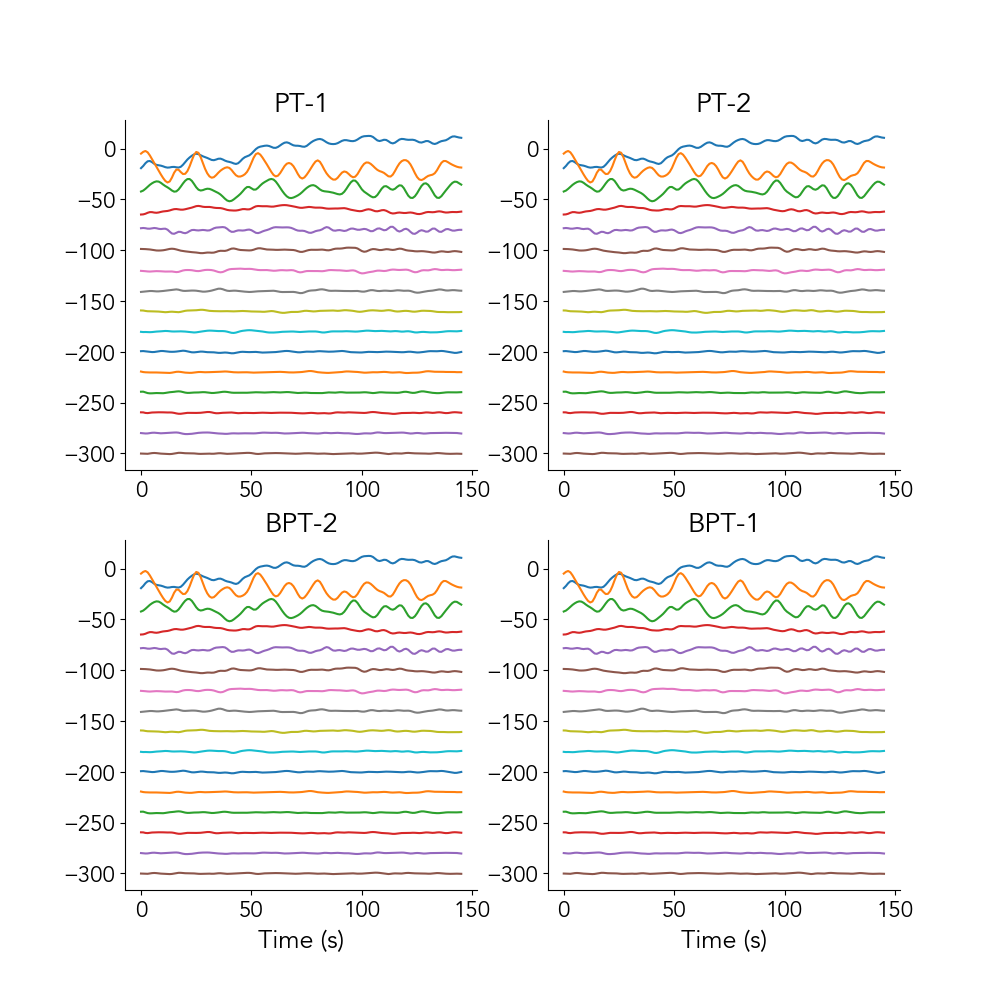

In [78]:
plot_bpt(np.tile(motion_frames_c.bpts_frames, (4,1,1)), shift = -20)

## UTE Lung Sequence Testing

In [38]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/phantom_ute_121725/Series3"

# # Load radial data
# radial = RadialArchive(inpdir)
# radial.get_ksp(force_reload=False)
# # Compress k-space
# split_xk_bpt_nm = SplitXkBPT(inp_dir=inpdir, verbose=True)
# split_xk_bpt_nm._get_raw_xk()
# split_xk_bpt_nm.xk_cleaned = split_xk_bpt_nm.xk_ordered
# split_xk_bpt_nm._compress_kspace()
# np.save(split_xk_bpt_nm.xk_fname, split_xk_bpt_nm.xk_cleaned)
# Recon image
no_motion_reference = NoMotionReference(inp_dir=inpdir, verbose=True)
no_motion_reference.run(force_reload=False)

INFO: Reference image and CSMs found. Opening...


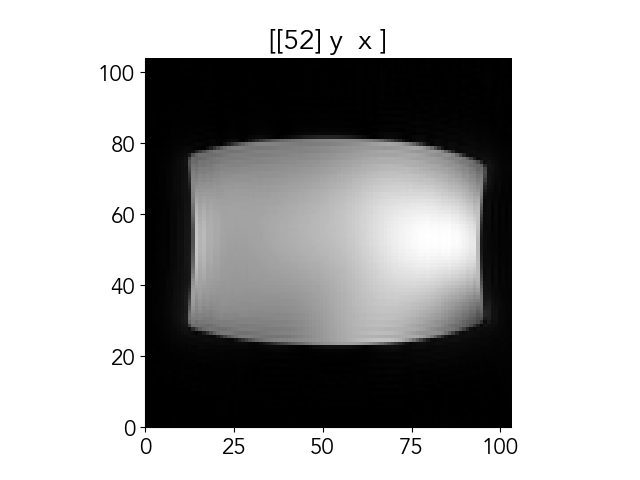

In [40]:
pl.ImagePlot(no_motion_reference.S)

In [41]:
# Path to radial ScanArchive folder -- my sequence (Rinni UTE)
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/phantom_ute_121725/Series9"

# # Load radial data
# radial = RadialArchive(inpdir)
# # radial.get_ksp(force_reload=False)
# # Compress k-space
# split_xk_bpt_nm = SplitXkBPT(inp_dir=inpdir, verbose=True)
# split_xk_bpt_nm._get_raw_xk()
# split_xk_bpt_nm.xk_cleaned = split_xk_bpt_nm.xk_ordered
# split_xk_bpt_nm._compress_kspace()
# np.save(split_xk_bpt_nm.xk_fname, split_xk_bpt_nm.xk_cleaned)
# Recon image
no_motion_reference = NoMotionReference(inp_dir=inpdir, verbose=True)
no_motion_reference.run(force_reload=False)

INFO: Reference image and CSMs not found. Extracting with crop factor 3...
INFO: Getting xk, coords, dcf, and bpts from radial data.
INFO: Cropping spokes by 3.
INFO: Preparing adjoint NUFFT operator and inputs.
INFO: Getting cartesian k-space of reference.
INFO: Getting coil sensitivity maps of reference.
INFO: Getting reference image.


Done.


SenseRecon:   0%|          | 0/30 [00:00<?, ?it/s]